Loaded sequence length: 4641652

=== Analyzing n=1 ===
States learned: 4
Generated synthetic sequence of length 100000
State	A	C	G	T
A	0.2958	0.2247	0.2083	0.2712
C	0.2757	0.2303	0.2939	0.2001
G	0.2271	0.3262	0.2295	0.2172
T	0.1858	0.2343	0.2824	0.2975
Base composition (A,C,G,T): real -> [0.23296, 0.25342, 0.27243, 0.24119]
Base composition (A,C,G,T): synth-> [0.24752, 0.25571, 0.25315, 0.24362]
KL divergence (k=1): 0.001696
Entropy (k=1): real=1.997472, synth=1.999742
Prediction accuracy (most likely next base): 0.303445
Motif ATG: real=1725, synth=1947
Motif TATA: real=146, synth=232
Motif GCG: real=2655, synth=2268

=== Analyzing n=2 ===
States learned: 16
Generated synthetic sequence of length 100000
State	A	C	G	T
AA	0.3224	0.2444	0.1876	0.2456
AC	0.2285	0.2918	0.2854	0.1943
AG	0.2381	0.3399	0.2128	0.2092
AT	0.2056	0.2792	0.2461	0.2692
CA	0.2356	0.2053	0.3223	0.2368
CC	0.3182	0.1759	0.3203	0.1856
CG	0.2046	0.3337	0.2506	0.2110
CT	0.1134	0.1810	0.4360	0.2696
GA	0.3124	0.2048	0.1590	

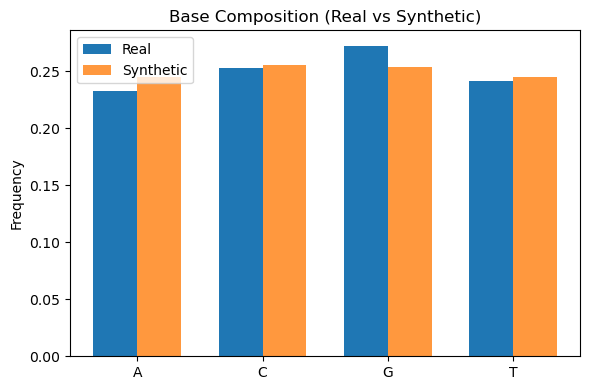

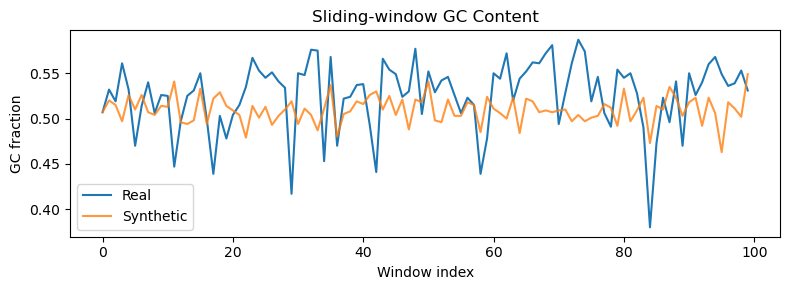

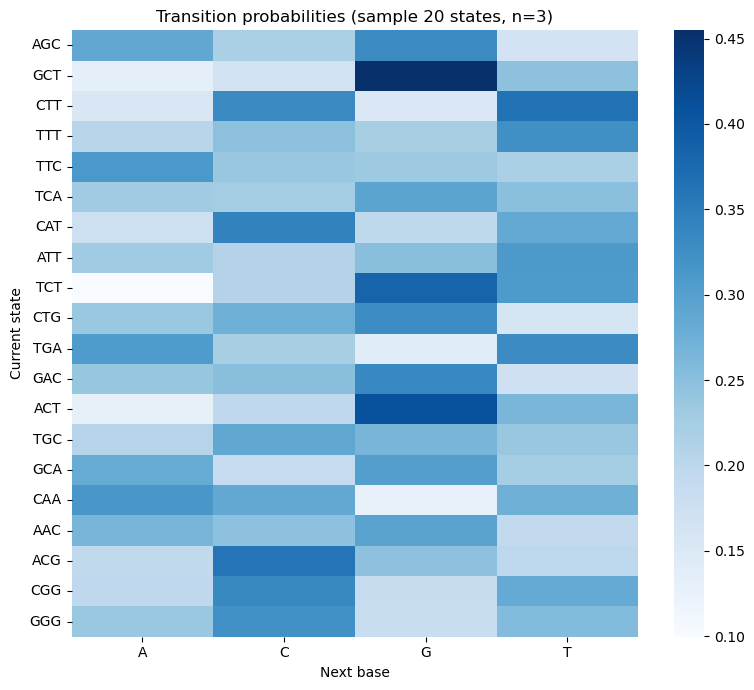


=== Analyzing n=4 ===
States learned: 256
Generated synthetic sequence of length 100000
State	A	C	G	T
AAAA	0.3266	0.2420	0.1742	0.2572
AAAC	0.2536	0.2715	0.2778	0.1971
AAAG	0.2677	0.3227	0.1994	0.2102
AAAT	0.2362	0.2756	0.2308	0.2574
AACA	0.2794	0.1811	0.3057	0.2338
AACC	0.3114	0.1770	0.3178	0.1938
AACG	0.1799	0.3525	0.2443	0.2233
AACT	0.1095	0.2113	0.4453	0.2339
AAGA	0.3310	0.1635	0.2183	0.2871
AAGC	0.2351	0.2656	0.3296	0.1697
AAGG	0.1904	0.3290	0.1877	0.2929
AAGT	0.1934	0.2055	0.3128	0.2884
AATA	0.3298	0.2296	0.1284	0.3123
AATC	0.3447	0.2169	0.2516	0.1868
AATG	0.2525	0.2992	0.2617	0.1866
AATT	0.2354	0.2106	0.2215	0.3325
ACAA	0.3384	0.2742	0.1348	0.2526
ACAC	0.1984	0.3907	0.2126	0.1983
ACAG	0.2073	0.3609	0.2466	0.1852
ACAT	0.1828	0.3436	0.2034	0.2702
ACCA	0.1890	0.2416	0.3415	0.2279
ACCC	0.2940	0.1526	0.3692	0.1843
ACCG	0.1997	0.3110	0.2628	0.2265
ACCT	0.0914	0.1525	0.4538	0.3023
ACGA	0.2799	0.2592	0.1290	0.3319
ACGC	0.2122	0.3091	0.2380	0.2407
ACGG	0.1756	0.3488	0.1760	0.2996
ACGT	0

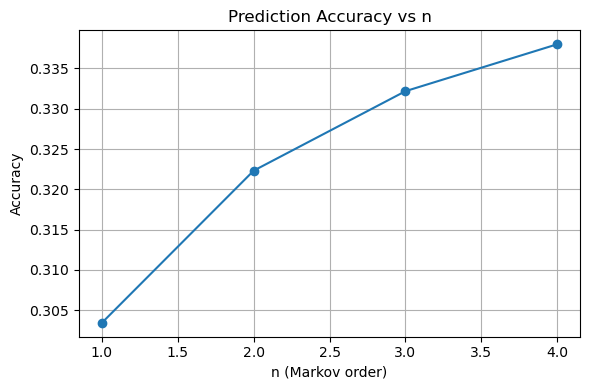

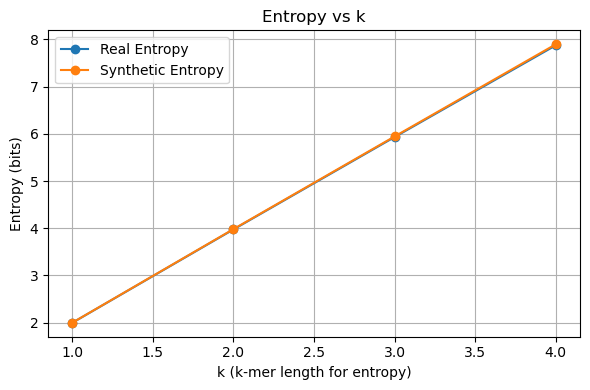


Summary table (n, accuracy, KL, H_real, H_synth):
n=1: acc=0.3034, KL=0.001696, H_real=1.9975, H_synth=1.9997
n=2: acc=0.3223, KL=0.003552, H_real=3.9750, H_synth=3.9820
n=3: acc=0.3322, KL=0.006171, H_real=5.9317, H_synth=5.9443
n=4: acc=0.3380, KL=0.012961, H_real=7.8743, H_synth=7.8964


In [7]:
import gzip
import urllib.request
import random
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys



LOCAL_FASTA_PATH = None


NCBI_FNA_GZ_URL = (
    "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/"
    "GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz"
)

OUTDIR = "results"
os.makedirs(OUTDIR, exist_ok=True)

def download_and_read_fasta_gz(url):
    
    print("Downloading (may take a while)...")
    resp = urllib.request.urlopen(url)
    with gzip.open(resp, "rt") as fh:
        seq_lines = []
        for line in fh:
            if line.startswith(">"):
                continue
            seq_lines.append(line.strip())
    raw = "".join(seq_lines).upper()
    # filter to A,C,G,T
    seq = "".join([c for c in raw if c in {"A","C","G","T"}])
    return seq

def read_local_fasta(path):
    
    print(f"Reading local FASTA: {path}")
    if path.endswith(".gz"):
        opener = gzip.open
        mode = "rt"
    else:
        opener = open
        mode = "r"
    seq_lines = []
    with opener(path, mode) as fh:
        for line in fh:
            if line.startswith(">"):
                continue
            seq_lines.append(line.strip())
    raw = "".join(seq_lines).upper()
    seq = "".join([c for c in raw if c in {"A","C","G","T"}])
    return seq

def load_sequence():
    
    if LOCAL_FASTA_PATH:
        return read_local_fasta(LOCAL_FASTA_PATH)
    else:
        return download_and_read_fasta_gz(NCBI_FNA_GZ_URL)

class NGramMarkovChain:
    def __init__(self, n=3):
        self.n = n
        self.transition_counts = {}   
        self.transition_matrix = {}  
        self.states = set()

    def fit(self, sequence):
        counts = {}
        seq_len = len(sequence)
        for i in range(seq_len - self.n):
            state = tuple(sequence[i:i+self.n])
            nxt = sequence[i + self.n]
            self.states.add(state)
            if state not in counts:
                counts[state] = Counter()
            counts[state][nxt] += 1
        self.transition_counts = counts
        # normalize
        matrix = {}
        for state, ctr in counts.items():
            total = sum(ctr.values())
            probs = {b: ctr[b]/total for b in ctr}
            matrix[state] = probs
        self.transition_matrix = matrix

    def predict_most_likely(self, state):
        if state not in self.transition_matrix:
            return random.choice(['A','C','G','T'])
        probs = self.transition_matrix[state]
        return max(probs, key=probs.get)

    def sample_next(self, state):
        probs = self.transition_matrix.get(state)
        if not probs:
            return random.choice(['A','C','G','T'])
        bases = list(probs.keys())
        weights = np.array([probs[b] for b in bases], dtype=float)
        # numerical safety
        if weights.sum() <= 0:
            return random.choice(['A','C','G','T'])
        weights = weights / weights.sum()
        return np.random.choice(bases, p=weights)

    def generate(self, start_state, length=1000):
        if not isinstance(start_state, tuple) or len(start_state) != self.n:
            raise ValueError("start_state must be a tuple of length n")
        seq = list(start_state)
        for _ in range(length - self.n):
            state = tuple(seq[-self.n:])
            nxt = self.sample_next(state)
            seq.append(nxt)
        return "".join(seq)

def base_composition(seq):
    c = Counter(seq)
    total = len(seq)
    return {b: c.get(b,0)/total for b in ['A','C','G','T']}

def kmer_frequency(seq, k=3):
    counts = Counter()
    for i in range(len(seq)-k+1):
        kmer = seq[i:i+k]
        counts[kmer] += 1
    total = sum(counts.values())
    return {kmer: count/total for kmer, count in counts.items()}

def entropy_from_freqs(freq_dict):
    probs = np.array(list(freq_dict.values()), dtype=float)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def kl_divergence(p_freqs, q_freqs, tiny=1e-12):
    keys = set(p_freqs.keys()).union(set(q_freqs.keys()))
    p = np.array([p_freqs.get(k, tiny) for k in keys], dtype=float)
    q = np.array([q_freqs.get(k, tiny) for k in keys], dtype=float)
    p = p / p.sum()
    q = q / q.sum()
    q = np.clip(q, tiny, None)
    return float(np.sum(p * np.log2(p / q)))

def prediction_accuracy(sequence, model):
    
    n = model.n
    correct = 0
    total = 0
    for i in range(len(sequence) - n):
        state = tuple(sequence[i:i+n])
        true_next = sequence[i+n]
        pred = model.predict_most_likely(state)
        if pred == true_next:
            correct += 1
        total += 1
    return correct / total if total>0 else 0.0

def gc_content_sliding(seq, window=1000, step=1000):
    arr = []
    for i in range(0, max(1, len(seq) - window + 1), step):
        w = seq[i:i+window]
        g = w.count('G')
        c = w.count('C')
        arr.append((g+c)/len(w))
    return arr

def motif_count(seq, motif):
    return seq.count(motif)

def plot_base_comp(real_freq, synth_freq, outpath=None):
    labels = ['A','C','G','T']
    real_vals = [real_freq[b] for b in labels]
    synth_vals = [synth_freq[b] for b in labels]
    x = np.arange(len(labels))
    width = 0.35
    plt.figure(figsize=(6,4))
    plt.bar(x - width/2, real_vals, width, label='Real')
    plt.bar(x + width/2, synth_vals, width, label='Synthetic', alpha=0.8)
    plt.xticks(x, labels)
    plt.ylabel('Frequency')
    plt.title('Base Composition (Real vs Synthetic)')
    plt.legend()
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200)
    plt.show()

def plot_gc_content(real_gc, synth_gc, outpath=None):
    plt.figure(figsize=(8,3))
    plt.plot(real_gc, label='Real')
    plt.plot(synth_gc, label='Synthetic', alpha=0.8)
    plt.xlabel('Window index')
    plt.ylabel('GC fraction')
    plt.title('Sliding-window GC Content')
    plt.legend()
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200)
    plt.show()

def plot_accuracy_entropy(ns, accuracies, real_ent, synth_ent, outpath=None):
    plt.figure(figsize=(6,4))
    plt.plot(ns, accuracies, marker='o', label='Prediction Accuracy')
    plt.xlabel('n (Markov order)')
    plt.ylabel('Accuracy')
    plt.title('Prediction Accuracy vs n')
    plt.grid(True)
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath.replace('.png','_accuracy.png'), dpi=200)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(ns, real_ent, marker='o', label='Real Entropy')
    plt.plot(ns, synth_ent, marker='o', label='Synthetic Entropy')
    plt.xlabel('k (k-mer length for entropy)')
    plt.ylabel('Entropy (bits)')
    plt.title('Entropy vs k')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath.replace('.png','_entropy.png'), dpi=200)
    plt.show()

def plot_transition_heatmap(model, max_states=20, outpath=None):
    states = list(model.transition_matrix.keys())[:max_states]
    matrix = np.zeros((len(states), 4))
    base_index = {'A':0,'C':1,'G':2,'T':3}
    for i, state in enumerate(states):
        probs = model.transition_matrix.get(state, {})
        for b,p in probs.items():
            matrix[i, base_index[b]] = p
    plt.figure(figsize=(8, max_states*0.25+2))
    sns.heatmap(matrix, xticklabels=['A','C','G','T'], yticklabels=["".join(s) for s in states], cmap='Blues', cbar=True)
    plt.title(f"Transition probabilities (sample {len(states)} states, n={model.n})")
    plt.xlabel("Next base")
    plt.ylabel("Current state")
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200)
    plt.show()

def print_full_transition_matrix(model):
    """
    Print the full transition probability matrix for all states in the model.
    """
    bases = ['A','C','G','T']
    states = sorted(model.transition_matrix.keys())
    header = "State\t" + "\t".join(bases)
    print(header)
    for state in states:
        probs = model.transition_matrix[state]
        row = [f"{probs.get(b,0.0):.4f}" for b in bases]
        print(f"{''.join(state)}\t" + "\t".join(row))
    
    return states, {state: model.transition_matrix[state] for state in states}

def main():
    seq = load_sequence()
    print(f"Loaded sequence length: {len(seq)}")

    ns = [1,2,3,4]
    accuracies = []
    real_entropies = []
    synth_entropies = []
    kldivs = []

   
    for n in ns:
        print(f"\n=== Analyzing n={n} ===")
        model = NGramMarkovChain(n=n)
        model.fit(seq)
        print(f"States learned: {len(model.transition_matrix)}")

        start_state = tuple(seq[:n])
        synth_len = 100000  
        synthetic = model.generate(start_state, length=synth_len)
        print(f"Generated synthetic sequence of length {len(synthetic)}")
        print_full_transition_matrix(model)
        
        real_base = base_composition(seq[:synth_len])
        synth_base = base_composition(synthetic)
        print("Base composition (A,C,G,T): real ->", [real_base[b] for b in ['A','C','G','T']])
        print("Base composition (A,C,G,T): synth->", [synth_base[b] for b in ['A','C','G','T']])

        k = n
        real_kmer = kmer_frequency(seq[:synth_len], k=k)
        synth_kmer = kmer_frequency(synthetic, k=k)
        kl = kl_divergence(real_kmer, synth_kmer)
        print(f"KL divergence (k={k}): {kl:.6f}")

        H_real = entropy_from_freqs(real_kmer)
        H_synth = entropy_from_freqs(synth_kmer)
        print(f"Entropy (k={k}): real={H_real:.6f}, synth={H_synth:.6f}")
        
        acc = prediction_accuracy(seq, model)
        print(f"Prediction accuracy (most likely next base): {acc:.6f}")

        motifs = ['ATG','TATA','GCG']
        for m in motifs:
            rc = motif_count(seq[:synth_len], m)
            sc = motif_count(synthetic, m)
            print(f"Motif {m}: real={rc}, synth={sc}")

        window = 1000
        real_gc = gc_content_sliding(seq[:synth_len], window=window, step=window)
        synth_gc = gc_content_sliding(synthetic, window=window, step=window)

        if n == 3:
            plot_base_comp(real_base, synth_base, outpath=os.path.join(OUTDIR,"base_comp_n3.png"))
            plot_gc_content(real_gc, synth_gc, outpath=os.path.join(OUTDIR,"gc_content_n3.png"))
            plot_transition_heatmap(model, max_states=20, outpath=os.path.join(OUTDIR,"transition_heatmap_n3.png"))

        accuracies.append(acc)
        real_entropies.append(H_real)
        synth_entropies.append(H_synth)
        kldivs.append(kl)

    plot_accuracy_entropy(ns, accuracies, real_entropies, synth_entropies, outpath=os.path.join(OUTDIR,"accuracy_entropy.png"))

    # Print summary table
    print("\nSummary table (n, accuracy, KL, H_real, H_synth):")
    for i,n in enumerate(ns):
        print(f"n={n}: acc={accuracies[i]:.4f}, KL={kldivs[i]:.6f}, H_real={real_entropies[i]:.4f}, H_synth={synth_entropies[i]:.4f}")

if __name__ == "__main__":
    main()



